## Setup

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))

import numpy as np
import pennylane as qml
import hybridlane as hqml
import bosonic_qiskit as bq
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from hybridlane.devices.bosonic_qiskit.simulate import make_cv_circuit
from hybridlane.measurements import FockTruncation
from hybridlane import sa
from hybridlane.devices.bosonic_qiskit import gates as bq_gates
from hybridlane.templates import ECDLayer, random_ecd_params

print("All imports successful.")

All imports successful.


## 1 — Circuit drawing

### 1.1 Single ECDLayer (depth 1)

/var/folders/8r/9nhc0m7x6k33tps3ybz08mlr0000gn/T/ipykernel_28305/3282331866.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


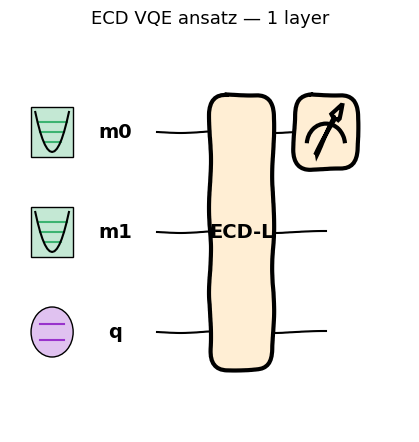

In [2]:
N_DEPTH = 5        # ansatz depth 
MAX_FOCK = 8       # Fock cutoff — 3 physical qubits per qumode

def ecd_ansatz_circuit(params, ndepth):
    """ECD VQE ansatz with ndepth layers."""
    params = np.reshape(params, (ndepth, 8))
    for d in range(ndepth):
        ECDLayer(*params[d], wires=["q", "m0", "m1"])
    return hqml.expval(hqml.N("m0"))

fig, ax = hqml.draw_mpl(ecd_ansatz_circuit, style="sketch")(np.zeros(8), 1)
ax.set_title("ECD VQE ansatz — 1 layer", fontsize=13)
plt.tight_layout()
plt.savefig("ecd_vqe_circuit_depth1.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.2 Full ansatz (depth 5)

/var/folders/8r/9nhc0m7x6k33tps3ybz08mlr0000gn/T/ipykernel_28305/2280815482.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


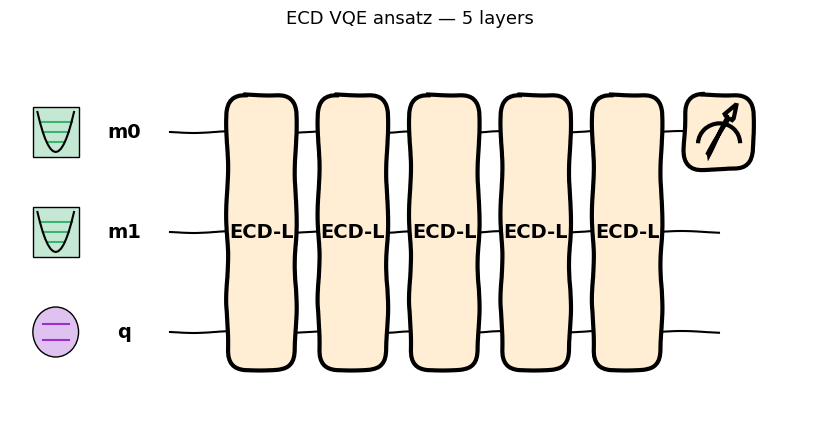

In [3]:
fig, ax = hqml.draw_mpl(ecd_ansatz_circuit, style="sketch")(np.zeros(8 * N_DEPTH), N_DEPTH)
ax.set_title(f"ECD VQE ansatz — {N_DEPTH} layers", fontsize=13)
plt.tight_layout()
plt.savefig("ecd_vqe_circuit_depth5.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
#  problem parameters 
VALUES     = [2, 5, 7, 3]
WEIGHTS    = [2.5, 3, 4, 3.5]
MAX_WEIGHT = 7
L_VAL      = 3   


def state_idx_to_vars(idx):
    """Map statevector index to (x_0..x_3, y_0..y_2) knapsack variables."""
    x3 = (idx >> 0) & 1   # qubit holds x_3
    x0 = (idx >> 1) & 1   # m0 Fock bit 0
    x1 = (idx >> 2) & 1   # m0 Fock bit 1
    x2 = (idx >> 3) & 1   # m0 Fock bit 2
    y0 = (idx >> 4) & 1   # m1 Fock bit 0
    y1 = (idx >> 5) & 1   # m1 Fock bit 1
    y2 = (idx >> 6) & 1   # m1 Fock bit 2
    return [x0, x1, x2, x3], [y0, y1, y2]

def knapsack_cost(x, y, values=VALUES, weights=WEIGHTS,
                  max_weight=MAX_WEIGHT, l_val=L_VAL):
    """Classical QUBO cost: -value + lambda * (W_max - weight - slack)^2."""
    value  = sum(values[i]  * x[i] for i in range(4))
    weight = sum(weights[i] * x[i] for i in range(4))
    slack  = y[0] * 1 + y[1] * 2 + y[2] * 4
    return -value + l_val * (max_weight - weight - slack)**2

# Pre-compute the diagonal of H 
DIM = 2 * MAX_FOCK * MAX_FOCK  # = 128
H_DIAG = np.array([
    knapsack_cost(*state_idx_to_vars(idx))
    for idx in range(DIM)
])

x_opt = [0, 1, 1, 0]
y_opt = [0, 0, 0]
opt_cost = knapsack_cost(x_opt, y_opt)
opt_idx = 0*1 + 0*2 + 1*4 + 1*8   # = 12
print(f"Optimal solution: items={{1,2}}, value=12, weight=7")
print(f"Optimal cost H = {opt_cost}  (should be -12)")
print(f"Optimal state index = {opt_idx}  (|q=0, m0=6, m1=0>)")
print(f"H_DIAG[{opt_idx}] = {H_DIAG[opt_idx]:.1f}")
print(f"H_DIAG minimum   = {H_DIAG.min():.1f}")
print(f"H_DIAG range:  [{H_DIAG.min():.0f}, {H_DIAG.max():.0f}]")

Optimal solution: items={1,2}, value=12, weight=7
Optimal cost H = -12.0  (should be -12)
Optimal state index = 12  (|q=0, m0=6, m1=0>)
H_DIAG[12] = -12.0
H_DIAG minimum   = -12.0
H_DIAG range:  [-12, 490]


In [5]:
ACCEPTED_GATES = (
    set(bq_gates.cv_gate_map)
    | set(bq_gates.dv_gate_map)
    | set(bq_gates.hybrid_gate_map)
    | set(bq_gates.misc_gate_map)
)

def get_statevector(params, ndepth):
    """Run ECD ansatz and return the 128-dimensional statevector."""
    def circuit_fn(p):
        p_r = np.reshape(p, (ndepth, 8))
        for d in range(ndepth):
            ECDLayer(*p_r[d], wires=["q", "m0", "m1"])
        return hqml.expval(hqml.N("m0"))  # placeholder

    tape = qml.tape.make_qscript(circuit_fn)(params)
    [decomposed], _ = qml.transforms.decompose(
        tape, gate_set=ACCEPTED_GATES, max_expansion=10
    )
    sa_res = sa.analyze(decomposed)
    dim_sizes = {
        w: (2 if isinstance(wt, sa.Qubit) else MAX_FOCK)
        for w, wt in sa_res.wire_types.items()
    }
    truncation = FockTruncation.all_fock_space(sa_res.wire_order, dim_sizes)
    qc, _ = make_cv_circuit(decomposed, truncation)
    state, _, _ = bq.util.simulate(qc, shots=None, return_fockcounts=False)
    return np.array(state)


def energy(params, ndepth):
    """Compute knapsack energy ⟨H⟩ for the ECD VQE ansatz."""
    sv = get_statevector(params, ndepth)
    probs = np.abs(sv) ** 2
    return float(probs @ H_DIAG)


# Sanity check: vacuum state should have high cost (no items selected)
E_vacuum = energy(np.zeros(8 * N_DEPTH), N_DEPTH)
print(f"Energy of vacuum (all params=0): {E_vacuum:.2f}")
print(f"Expected: l_val * max_weight^2 = {L_VAL * MAX_WEIGHT**2}")

Energy of vacuum (all params=0): 147.00
Expected: l_val * max_weight^2 = 147


In [6]:
import os
PARAMS_FILE = "ecd_vqe_optimal_params.npy"

if os.path.exists(PARAMS_FILE):
    optimal_params = np.load(PARAMS_FILE)
    energy_history  = []           # empty — optimisation was skipped
    result          = None
    print(f"Loaded optimal_params from '{PARAMS_FILE}' — skipping optimisation.")
    print(f"  params shape: {optimal_params.shape}")
    print(f"  energy at loaded params: {energy(optimal_params, N_DEPTH):.4f}")
else:
    print(f"No saved params found at '{PARAMS_FILE}'. Run the VQE cell below.")

No saved params found at 'ecd_vqe_optimal_params.npy'. Run the VQE cell below.


In [7]:
from scipy.optimize import approx_fprime

MAX_ITER   = 300
SEED       = 42
N_RESTARTS = 5
EPS_GRAD   = 1e-2  

def grad_fn(params):
    """Numerical gradient via forward finite differences (eps=1e-2)."""
    return approx_fprime(params, lambda p: energy(p, N_DEPTH), EPS_GRAD)

energy_history = []
best_result    = None

print(f"Starting VQE  (ndepth={N_DEPTH}, max_fock={MAX_FOCK})")
print(f"Optimal energy = {H_DIAG.min():.1f}")
print(f"Optimizer: BFGS + explicit finite-diff gradient (eps={EPS_GRAD})")
print(f"Restarts: {N_RESTARTS}  x  maxiter={MAX_ITER}")
print("-" * 55)

for restart in range(N_RESTARTS):
    rng_i   = np.random.default_rng(SEED + restart)
    p0_i    = random_ecd_params(N_DEPTH, rng=rng_i)
    hist_i  = []

    def cost_i(p, _hist=hist_i):
        e = energy(p, N_DEPTH)
        _hist.append(e)
        return e

    res_i = minimize(
        cost_i,
        p0_i,
        method="BFGS",
        jac=grad_fn,
        options={"maxiter": MAX_ITER, "gtol": 1e-3},
    )
    print(f"  restart {restart+1}/{N_RESTARTS}  energy={res_i.fun:.4f}  "
          f"evals={len(hist_i)}  msg={res_i.message}")

    if best_result is None or res_i.fun < best_result.fun:
        best_result    = res_i
        energy_history = hist_i

result         = best_result
optimal_params = result.x
print(f"\nBest energy:    {result.fun:.4f}")
print(f"Optimal energy: {H_DIAG.min():.1f}")

Starting VQE  (ndepth=5, max_fock=8)
Optimal energy = -12.0
Optimizer: BFGS + explicit finite-diff gradient (eps=0.01)
Restarts: 5  x  maxiter=300
-------------------------------------------------------
  restart 1/5  energy=-1.4646  evals=99  msg=Desired error not necessarily achieved due to precision loss.
  restart 2/5  energy=-10.2391  evals=83  msg=Desired error not necessarily achieved due to precision loss.
  restart 3/5  energy=0.5092  evals=89  msg=Desired error not necessarily achieved due to precision loss.
  restart 4/5  energy=-10.7592  evals=90  msg=Desired error not necessarily achieved due to precision loss.
  restart 5/5  energy=-11.1984  evals=74  msg=Desired error not necessarily achieved due to precision loss.

Best energy:    -11.1984
Optimal energy: -12.0


In [8]:
# ── Save / load optimal parameters ──────────────────────────────────────
PARAMS_FILE = "ecd_vqe_optimal_params.npy"

np.save(PARAMS_FILE, optimal_params)
print(f"Saved optimal_params ({len(optimal_params)} values) to '{PARAMS_FILE}'")

# To reload in a future session:
#   optimal_params = np.load(PARAMS_FILE)
#   print(f"Loaded optimal_params from '{PARAMS_FILE}'")

Saved optimal_params (40 values) to 'ecd_vqe_optimal_params.npy'


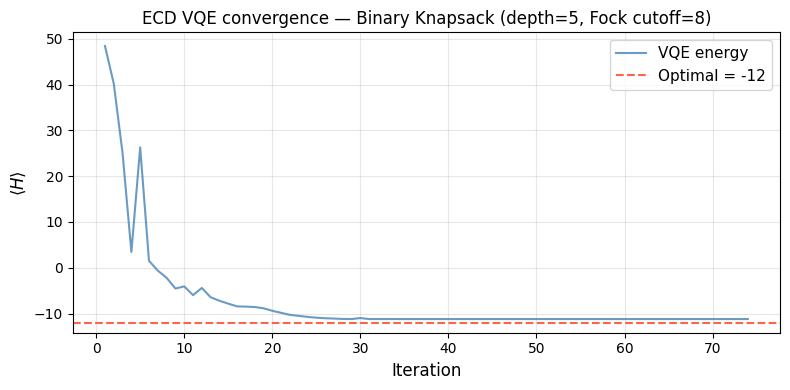

Initial energy:  48.42
Final energy:    -11.20
Optimal energy:  -12.0


In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

iters = np.arange(1, len(energy_history) + 1)
ax.plot(iters, energy_history, lw=1.5, color="steelblue", alpha=0.8, label="VQE energy")
ax.axhline(H_DIAG.min(), ls="--", color="tomato", lw=1.5, label=f"Optimal = {H_DIAG.min():.0f}")

ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel(r"$\langle H \rangle$", fontsize=12)
ax.set_title(f"ECD VQE convergence — Binary Knapsack (depth={N_DEPTH}, Fock cutoff={MAX_FOCK})",
             fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ecd_vqe_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Initial energy:  {energy_history[0]:.2f}")
print(f"Final energy:    {energy_history[-1]:.2f}")
print(f"Optimal energy:  {H_DIAG.min():.1f}")

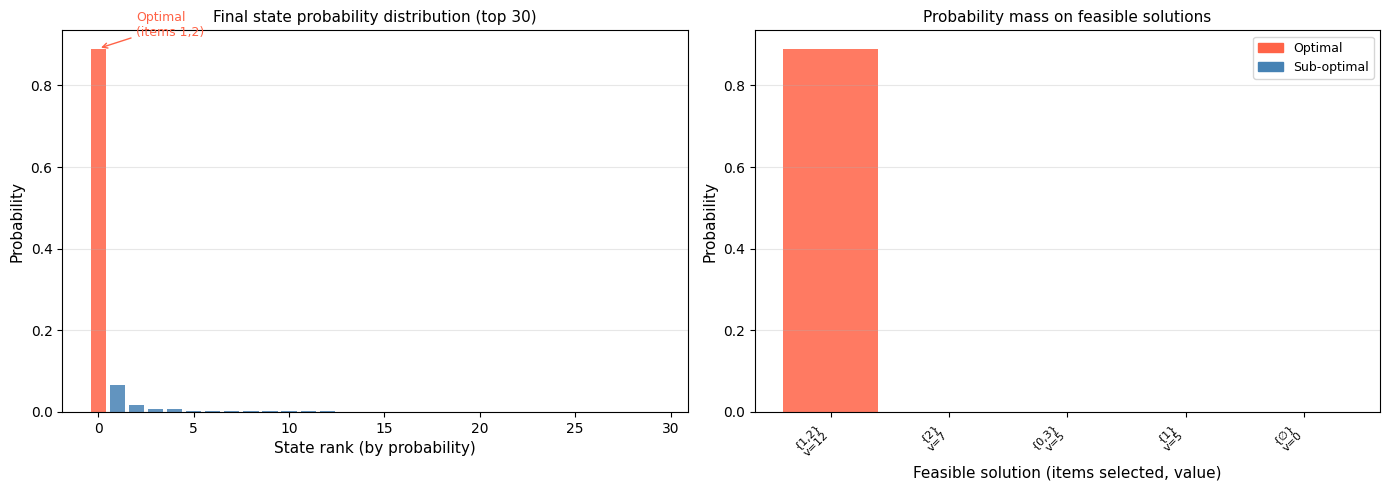

Optimal state index: 12  (|q=0, m0=6, m1=0>)
Probability at optimal state: 0.8906
Total probability on feasible states: 0.8906
Probability at optimal feasible state: 0.8906


In [10]:
# Get the final statevector
sv_final = get_statevector(optimal_params, N_DEPTH)
probs_final = np.abs(sv_final) ** 2

# Optimal state: x*=(0,1,1,0), y=(0,0,0) → state index 12 
optimal_state_idx = 12  # |q=0, m0=6, m1=0>

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Left: full probability bar chart (top 30 states) ----
ax1 = axes[0]
top_n = 30
top_idx = np.argsort(probs_final)[::-1][:top_n]
colors = ["tomato" if i == optimal_state_idx else "steelblue" for i in top_idx]
ax1.bar(range(top_n), probs_final[top_idx], color=colors, edgecolor="none", alpha=0.85)

if optimal_state_idx in top_idx:
    pos = np.where(top_idx == optimal_state_idx)[0][0]
    ax1.annotate(
        "Optimal\n(items 1,2)",
        xy=(pos, probs_final[optimal_state_idx]),
        xytext=(pos + 2, probs_final[optimal_state_idx] + 0.03),
        arrowprops=dict(arrowstyle="->", color="tomato"),
        color="tomato", fontsize=9,
    )

ax1.set_xlabel("State rank (by probability)", fontsize=11)
ax1.set_ylabel("Probability", fontsize=11)
ax1.set_title("Final state probability distribution (top 30)", fontsize=11)
ax1.grid(axis="y", alpha=0.3)

# ---- Right: probability on feasible states ----
ax2 = axes[1]

feasible_idx = []
feasible_cost = []
feasible_prob = []
feasible_label = []
for idx in range(DIM):
    x, y = state_idx_to_vars(idx)
    weight = sum(WEIGHTS[i] * x[i] for i in range(4))
    slack  = y[0] * 1 + y[1] * 2 + y[2] * 4
    if abs(MAX_WEIGHT - weight - slack) < 0.01:
        feasible_idx.append(idx)
        feasible_cost.append(knapsack_cost(x, y))
        feasible_prob.append(probs_final[idx])
        value = sum(VALUES[i] * x[i] for i in range(4))
        items = [str(i) for i in range(4) if x[i] == 1]
        feasible_label.append(f"{{{','.join(items) or '∅'}}}\nv={value:.0f}")

if feasible_idx:
    order = np.argsort(feasible_cost)
    feas_c = [feasible_cost[i] for i in order]
    feas_p = [feasible_prob[i] for i in order]
    feas_l = [feasible_label[i] for i in order]
    feas_opt = [c == min(feasible_cost) for c in feas_c]

    cols = ["tomato" if o else "steelblue" for o in feas_opt]
    ax2.bar(range(len(feas_c)), feas_p, color=cols, edgecolor="none", alpha=0.85)
    ax2.set_xticks(range(len(feas_c)))
    ax2.set_xticklabels(feas_l, fontsize=8, rotation=45, ha="right")
    ax2.set_xlabel("Feasible solution (items selected, value)", fontsize=11)
    ax2.set_ylabel("Probability", fontsize=11)
    ax2.set_title("Probability mass on feasible solutions", fontsize=11)
    ax2.grid(axis="y", alpha=0.3)

    from matplotlib.patches import Patch
    ax2.legend(handles=[Patch(color="tomato", label="Optimal"),
                        Patch(color="steelblue", label="Sub-optimal")], fontsize=9)
else:
    ax2.text(0.5, 0.5, "No feasible solutions found\n(increase max_iter or depth)",
             ha="center", va="center", transform=ax2.transAxes, fontsize=11)

plt.tight_layout()
plt.savefig("ecd_vqe_probability_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Optimal state index: {optimal_state_idx}  (|q=0, m0=6, m1=0>)")
print(f"Probability at optimal state: {probs_final[optimal_state_idx]:.4f}")
if feasible_idx:
    total_feasible_prob = sum(feas_p)
    opt_prob = feas_p[order.tolist().index(feas_opt.index(True))] if True in feas_opt else 0
    print(f"Total probability on feasible states: {total_feasible_prob:.4f}")
    print(f"Probability at optimal feasible state: {probs_final[optimal_state_idx]:.4f}")

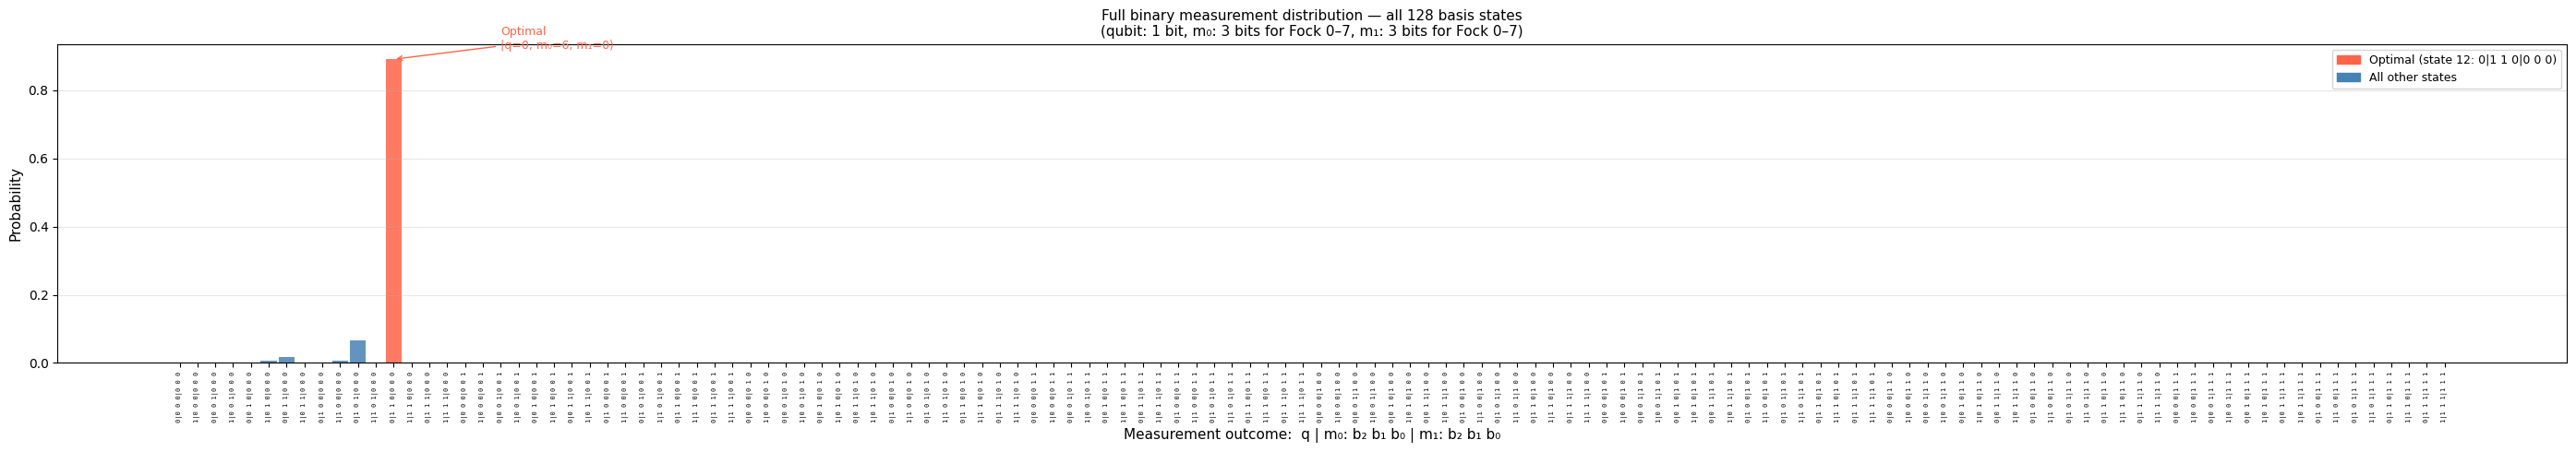

Optimal state [12]  label: 0|1 1 0|0 0 0
Optimal state probability:  0.8906
States with prob > 0.01:    3
Total probability mass:     1.000000


In [11]:
# Binary measurement distribution over all 128 computational basis states
# Label format:  q | m0_b2 m0_b1 m0_b0 | m1_b2 m1_b1 m1_b0
# where each bit group is MSB→LSB of the Fock index for that mode.

def state_to_binary_label(idx):
    q      = (idx >> 0) & 1
    m0_b   = [(idx >> (3 - k)) & 1 for k in range(3)]   # bits 3,2,1 → MSB first
    m1_b   = [(idx >> (6 - k)) & 1 for k in range(3)]   # bits 6,5,4 → MSB first
    m0_str = " ".join(str(b) for b in m0_b)
    m1_str = " ".join(str(b) for b in m1_b)
    return f"{q}|{m0_str}|{m1_str}"

labels = [state_to_binary_label(i) for i in range(DIM)]
probs  = np.abs(sv_final) ** 2
colors = ["tomato" if i == optimal_state_idx else "steelblue" for i in range(DIM)]

fig, ax = plt.subplots(figsize=(28, 5))
ax.bar(range(DIM), probs, color=colors, edgecolor="none", alpha=0.85, width=0.9)

ax.set_xticks(range(DIM))
ax.set_xticklabels(labels, rotation=90, fontsize=5, fontfamily="monospace")
ax.set_xlabel("Measurement outcome:  q | m₀: b₂ b₁ b₀ | m₁: b₂ b₁ b₀", fontsize=11)
ax.set_ylabel("Probability", fontsize=11)
ax.set_title(
    f"Full binary measurement distribution — all {DIM} basis states\n"
    f"(qubit: 1 bit, m₀: 3 bits for Fock 0–{MAX_FOCK-1}, m₁: 3 bits for Fock 0–{MAX_FOCK-1})",
    fontsize=11,
)
ax.grid(axis="y", alpha=0.3)

# Annotate optimal state
ax.annotate(
    f"Optimal\n|q=0, m₀=6, m₁=0⟩",
    xy=(optimal_state_idx, probs[optimal_state_idx]),
    xytext=(optimal_state_idx + 6, probs[optimal_state_idx] + 0.03),
    arrowprops=dict(arrowstyle="->", color="tomato"),
    color="tomato", fontsize=9,
)

from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(color="tomato",    label=f"Optimal (state {optimal_state_idx}: {labels[optimal_state_idx]})"),
             Patch(color="steelblue", label="All other states")],
    fontsize=9,
)

plt.tight_layout()
plt.savefig("ecd_vqe_binary_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Optimal state [{optimal_state_idx}]  label: {labels[optimal_state_idx]}")
print(f"Optimal state probability:  {probs[optimal_state_idx]:.4f}")
print(f"States with prob > 0.01:    {(probs > 0.01).sum()}")
print(f"Total probability mass:     {probs.sum():.6f}")